# GIAI ĐOẠN 2: XÂY DỰNG MÔ HÌNH DỰ ĐOÁN NĂNG LỰC HỌC SINH, ĐỘ KHÓ VÀ ĐỘ PHÂN LOẠI HỌC SINH QUA CÁC CÂU HỎI

In [18]:
import pandas as pd
import numpy as np

df_train = pd.read_csv('data/train_cleaned.csv')
df_parts = pd.read_csv('data/train_merged_with_parts.csv')

print(f"Đã nạp thành công {len(df_train)} dòng dữ liệu!")
df_train.head()

Đã nạp thành công 4812958 dòng dữ liệu!


,row_id,timestamp,user_id,content_id,content_type_id,task_container_id,user_answer,answered_correctly,prior_question_elapsed_time,prior_question_had_explanation
0,0,0,115,5692,0,1,3,1,NaN,NaN
1,1,56943,115,5716,0,2,2,1,37000.0,False
2,2,118363,115,128,0,0,0,1,55000.0,False
3,3,131167,115,7860,0,3,0,1,19000.0,False
4,4,137965,115,7922,0,4,1,1,11000.0,False


### MÔ HÌNH KHẢO THÍ CỔ ĐIỂN (CTT - Classical Test Theory)
Mô hình CTT đánh giá chất lượng câu hỏi bị phụ thuộc vào nhóm học sinh làm bài, năng lực của học sinh được tính bằng **tổng điểm** (total score).
- **Độ khó ($p$):** Tỷ lệ học sinh làm đúng CH/ Tỷ lệ học sinh làm CH. Giá trị càng cao, câu hỏi càng dễ.
- **Độ phân biệt ($r):** so sánh điểm tổng của những em làm đúng câu đó với điểm tổng của những em làm sai. Nếu những em điểm cao thường làm đúng, và những em điểm thấp thường làm sai, câu hỏi đó có độ phân biệt tốt (r > 0.3). Nếu học sinh yếu khoanh lụi trúng nhiều hơn học sinh giỏi suy luận, $r$ sẽ bị âm (câu hỏi rác).

In [19]:
# ==========================================
# MÔ HÌNH KHẢO THÍ CỔ ĐIỂN (CTT)
# ==========================================
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

print("ĐANG CHẠY MÔ HÌNH CỔ ĐIỂN (CTT)...")

# 1. TÍNH NĂNG LỰC HỌC SINH (Tổng số câu trả lời đúng)
student_ctt = df_train.groupby('user_id')['answered_correctly'].sum().reset_index()
student_ctt.rename(columns={'answered_correctly': 'ability_total_score'}, inplace=True)
df_ctt_data = df_train.merge(student_ctt, on='user_id', how='inner')

print("\n1. Năng lực học sinh theo CTT (Top 3 học sinh điểm cao nhất):")
display(student_ctt.sort_values(by='ability_total_score', ascending=False).head(3))

# Lọc câu hỏi có >= 50 lượt làm
valid_items = df_train['content_id'].value_counts()[lambda x: x >= 50].index

# 2 & 3. TÍNH ĐỘ KHÓ VÀ ĐỘ PHÂN BIỆT CÂU HỎI
ctt_results = []
for q_id in valid_items:
    df_q = df_ctt_data[df_ctt_data['content_id'] == q_id]
    if df_q['answered_correctly'].nunique() == 2:
        
        # Độ khó (p-value): Tỷ lệ làm đúng (Càng cao càng dễ)
        p_difficulty = df_q['answered_correctly'].mean()
        
        # Độ phân biệt (Point-Biserial): Tương quan giữa việc làm đúng câu này và tổng điểm
        pbis_discrimination = df_q['answered_correctly'].corr(df_q['ability_total_score'])
        
        ctt_results.append({
            'content_id': q_id, 
            'CTT_Difficulty_p': p_difficulty, 
            'CTT_Discrimination_pbis': pbis_discrimination
        })

df_ctt = pd.DataFrame(ctt_results).dropna()

print("\n2 & 3. Thông số Câu hỏi theo CTT (Top 3 câu phân biệt tốt nhất):")
display(df_ctt.sort_values(by='CTT_Discrimination_pbis', ascending=False).head(3))

ĐANG CHẠY MÔ HÌNH CỔ ĐIỂN (CTT)...

1. Năng lực học sinh theo CTT (Top 3 học sinh điểm cao nhất):


,user_id,ability_total_score
10199,73289878,11809
5485,39919444,11123
5893,42525121,10506



2 & 3. Thông số Câu hỏi theo CTT (Top 3 câu phân biệt tốt nhất):


,content_id,CTT_Difficulty_p,CTT_Discrimination_pbis
10121,8275,0.534884,0.501373
10822,11311,0.515152,0.488851
10922,11209,0.365079,0.450108


### MÔ HÌNH KHẢO THÍ HIỆN ĐẠI (IRT 2PL - Item Response Theory)
Mô hình IRT sử dụng thuật toán Học máy (Logistic Regression) để xây dựng Đường cong Đặc trưng Câu hỏi (ICC), giúp bóc tách tham số câu hỏi hoàn toàn độc lập với năng lực học sinh.
- **Độ phân biệt ($a$):** Thể hiện qua độ dốc của đường cong. Trị số $a$ càng cao, đường thẳng càng dốc đứng, câu hỏi phân loại học sinh càng sắc bén.
- **Độ khó thực sự ($b$):** Mốc năng lực ($\theta$) mà tại đó học sinh có đúng 50% cơ hội trả lời đúng.

In [20]:
# Gom nhóm toàn bộ dữ liệu theo từng học sinh (user_id)
nhom_hoc_sinh = df_train.groupby('user_id')

# Tính tỷ lệ đúng (mean) và số câu đã làm (count)
student_ability = nhom_hoc_sinh['answered_correctly'].agg(['mean', 'count']).reset_index()
student_ability.rename(columns={'mean': 'ability_score', 'count': 'total_answered'}, inplace=True)

print("Top 5 học sinh có năng lực cao nhất:")
display(student_ability.sort_values(by='ability_score', ascending=False).head())

ĐANG CHẠY MÔ HÌNH HIỆN ĐẠI (IRT)...

1. Năng lực học sinh theo IRT (Top 3 học sinh có Theta cao nhất):


,user_id,ability_theta
13675,98596877,1.0
6304,45312560,1.0
6650,48102728,1.0



2 & 3. Thông số Câu hỏi theo IRT (Top 3 câu phân biệt tốt nhất):


,content_id,IRT_Discrimination_a,IRT_Difficulty_b
30,10687,8.721984,0.403083
715,6906,7.086825,0.319243
1150,2074,6.396665,0.626858


### Bước 1.2: Tính độ khó câu hỏi

In [13]:
# Gom nhóm toàn bộ dữ liệu theo từng id câu hỏi (content_id) để tính tỉ lệ trả lời đúng cho mỗi câu hỏi

question_diff = df_train.groupby('content_id')['answered_correctly'].agg(['mean', 'count']).reset_index()
question_diff.rename(columns={'mean': 'correct_rate', 'count': 'times_asked'}, inplace=True)

# Tham số IRT: Độ khó = 1 - Tỷ lệ đúng
question_diff['difficulty_score'] = 1 - question_diff['correct_rate']

print("Top 5 câu hỏi khó nhất:")
question_diff.sort_values(by='difficulty_score', ascending=False).head()

Top 5 câu hỏi khó nhất:


content_id  correct_rate  times_asked  difficulty_score
1308        1308           0.0            4               1.0
8470        8504           0.0            1               1.0
2077        2080           0.0            1               1.0
8015        8049           0.0            1               1.0
4383        4393           0.0            1               1.0

Trực quan hóa (Scatter Plot)

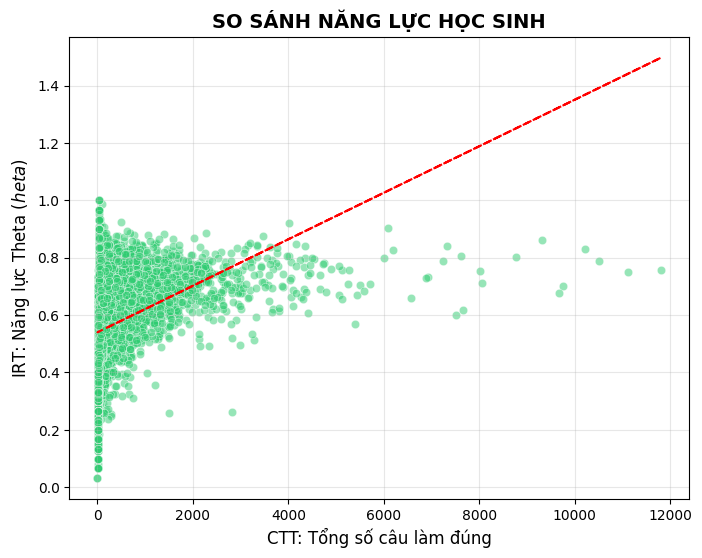

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ghép dữ liệu Năng lực từ CTT và IRT
df_student_compare = student_ctt.merge(student_irt, on='user_id', how='inner')

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_student_compare, 
    x='ability_total_score', 
    y='ability_theta', 
    alpha=0.5, 
    color='#2ecc71'
)

# Vẽ đường xu hướng
df_stu_clean = df_student_compare.dropna(subset=['ability_total_score', 'ability_theta'])
m1, b1 = np.polyfit(df_stu_clean['ability_total_score'], df_stu_clean['ability_theta'], 1)
plt.plot(df_stu_clean['ability_total_score'], m1*df_stu_clean['ability_total_score'] + b1, color='red', linestyle='--')

plt.title('SO SÁNH NĂNG LỰC HỌC SINH', fontsize=14, fontweight='bold')
plt.xlabel('CTT: Tổng số câu làm đúng', fontsize=12)
plt.ylabel('IRT: Năng lực Theta ($\theta$)', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

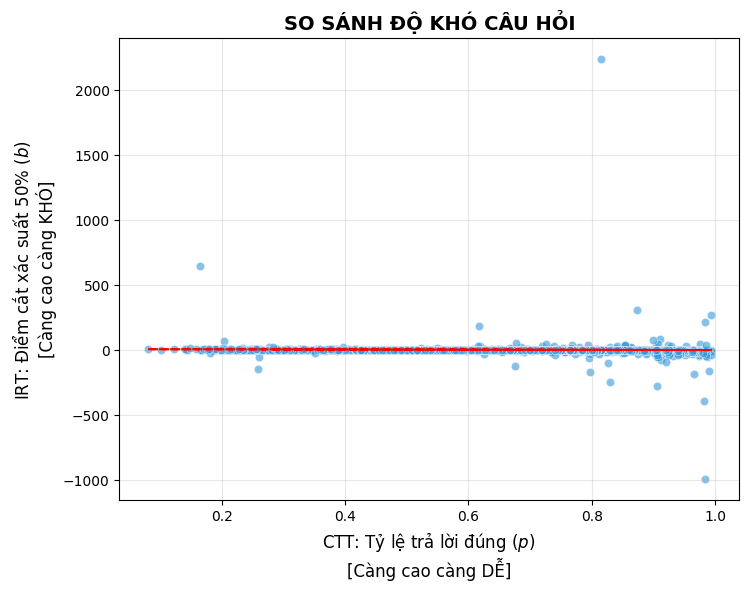

In [23]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_compare, 
    x='CTT_Difficulty_p', 
    y='IRT_Difficulty_b', 
    alpha=0.6, 
    color='#3498db'
)

# Vẽ đường xu hướng
df_diff_clean = df_compare.dropna(subset=['CTT_Difficulty_p', 'IRT_Difficulty_b'])
m2, b2 = np.polyfit(df_diff_clean['CTT_Difficulty_p'], df_diff_clean['IRT_Difficulty_b'], 1)
plt.plot(df_diff_clean['CTT_Difficulty_p'], m2*df_diff_clean['CTT_Difficulty_p'] + b2, color='red', linestyle='--')

plt.title('SO SÁNH ĐỘ KHÓ CÂU HỎI', fontsize=14, fontweight='bold')
plt.xlabel('CTT: Tỷ lệ trả lời đúng ($p$) \n[Càng cao càng DỄ]', fontsize=12)
plt.ylabel('IRT: Điểm cắt xác suất 50% ($b$) \n[Càng cao càng KHÓ]', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

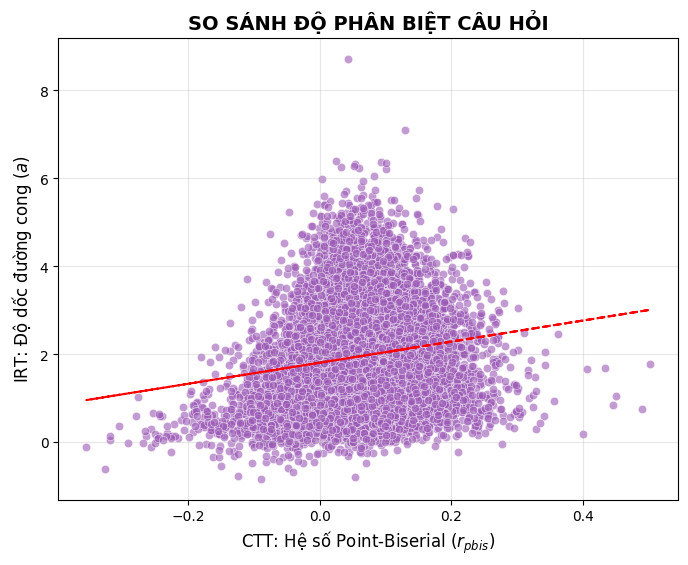

In [24]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_compare, 
    x='CTT_Discrimination_pbis', 
    y='IRT_Discrimination_a', 
    alpha=0.6, 
    color='#9b59b6'
)

# Vẽ đường xu hướng
df_disc_clean = df_compare.dropna(subset=['CTT_Discrimination_pbis', 'IRT_Discrimination_a'])
m3, b3 = np.polyfit(df_disc_clean['CTT_Discrimination_pbis'], df_disc_clean['IRT_Discrimination_a'], 1)
plt.plot(df_disc_clean['CTT_Discrimination_pbis'], m3*df_disc_clean['CTT_Discrimination_pbis'] + b3, color='red', linestyle='--')

plt.title('SO SÁNH ĐỘ PHÂN BIỆT CÂU HỎI', fontsize=14, fontweight='bold')
plt.xlabel('CTT: Hệ số Point-Biserial ($r_{pbis}$)', fontsize=12)
plt.ylabel('IRT: Độ dốc đường cong ($a$)', fontsize=12)
plt.grid(alpha=0.3)
plt.show()